# Water Dam

 ![Tux, the Linux mascot](figs/dam_fig.png)

# Boundary conditions

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [3]:
numericldata = pd.read_excel('/Users/hervesv/Documents/CloudDrive/Fac/M1/RWTH_ML/Dam Flow/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

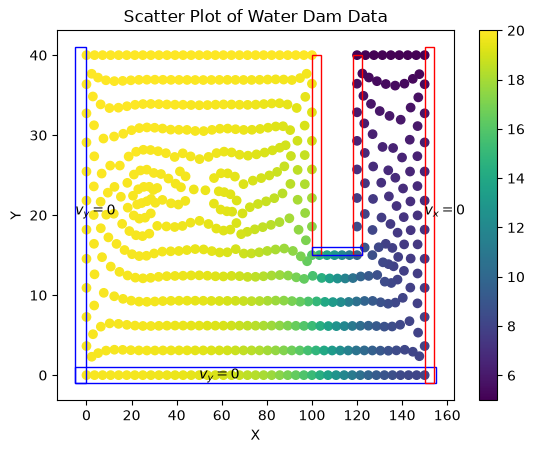

In [15]:
fig, ax = plt.subplots()
    
scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

# show boundaries

rect1 = patches.Rectangle(
    (-5, -1),            # Bottom-left corner coordinate
    160,                 # Width along X-axis
    2,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect1)
ax.text(50, -0.5, "$v_y = 0$")

rect2 = patches.Rectangle(
    (-5, -1),            # Bottom-left corner coordinate
    5,                 # Width along X-axis
    42,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect2)
ax.text(-5, 20, "$v_y = 0$")


rect3 = patches.Rectangle(
    (150, -1),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    42,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect3)
ax.text(150, 20, "$v_x = 0$")



rect4 = patches.Rectangle(
    (100, 15),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    25,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect4)



rect5 = patches.Rectangle(
    (118, 15),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    25,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect5)


rect6 = patches.Rectangle(
    (100, 15),            # Bottom-left corner coordinate
    22,                 # Width along X-axis
    1,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect6)



plt.show()

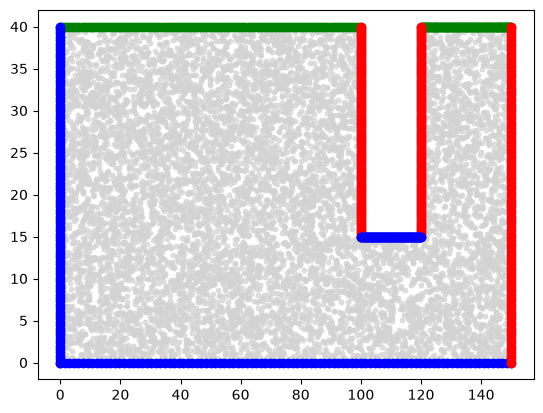

In [31]:
h1 = 20
h2 = 5
hd = 25

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = 150   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - HD    # bottom of dam

num_bc = 100

y1 = np.ones(num_bc) * y_top
x1 = np.linspace(x_left, x_dleft, num_bc)

y2 = np.ones(num_bc) * y_top
x2 = np.linspace(x_dright, x_right, num_bc)

x3 = np.ones(num_bc) * x_dleft
y3 = np.linspace(y_dbot, y_top, num_bc)

x4 = np.ones(num_bc) * x_dright
y4 = np.linspace(y_dbot, y_top, num_bc)

y5 = np.ones(num_bc) * y_dbot
x5 = np.linspace(x_dleft, x_dright, num_bc)

y6 = np.zeros(num_bc)
x6 = np.linspace(0, x_right, num_bc)

x7 = np.ones(num_bc) * x_right
y7 = np.linspace(0, y_top, num_bc)

x8 = np.ones(num_bc) * x_left
y8 = np.linspace(0, y_top, num_bc)

def sample_interior_points(num_points=1000):
    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_left, x_right)
        y_candidate = np.random.uniform(y_bot, y_top)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dleft <= x_candidate <= x_dright) and (y_dbot <= y_candidate <= y_top)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.array(sampled_x), np.array(sampled_y)

# Generate 1,000 interior points
x_internal, y_internal = sample_interior_points(num_points=10000)


y_color = "blue" # vy = 0
x_color = "red"  # vx = 0
val_color = "green"

plt.scatter(x_internal, y_internal, color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7)

plt.scatter(x1, y1, color=val_color)
plt.scatter(x2, y2, color=val_color)
plt.scatter(x3, y3, color=x_color)
plt.scatter(x4, y4, color=x_color)
plt.scatter(x5, y5, color=y_color)
plt.scatter(x6, y6, color=y_color)
plt.scatter(x7, y7, color=x_color)
plt.scatter(x8, y8, color=y_color)




plt.show()